In [1]:
# Cell 1 - Imports and load data for Day 6

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_DIR    = os.path.dirname(os.path.abspath(""))
CLEAN_PATH  = os.path.join(BASE_DIR, "data", "processed")
CHART_PATH  = os.path.join(BASE_DIR, "reports", "charts")
SCRIPT_PATH = os.path.join(BASE_DIR, "scripts")
os.makedirs(CHART_PATH, exist_ok=True)

# load all datasets needed for Day 6
nav_df   = pd.read_csv(os.path.join(CLEAN_PATH, "clean_nav.csv"),
                        parse_dates=["date"])
fund_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_fund_master.csv"))
tx_df    = pd.read_csv(os.path.join(CLEAN_PATH, "clean_transactions.csv"),
                        parse_dates=["transaction_date"])
port_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_portfolio_holdings.csv"))
perf_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_performance.csv"))
sharpe_df = pd.read_csv(os.path.join(CLEAN_PATH, "sharpe_values.csv"))

# sort nav data
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print("All data loaded successfully")
print(f"  nav_df   : {nav_df.shape[0]:,} rows")
print(f"  fund_df  : {fund_df.shape[0]:,} rows")
print(f"  tx_df    : {tx_df.shape[0]:,} rows")
print(f"  port_df  : {port_df.shape[0]:,} rows")
print(f"  perf_df  : {perf_df.shape[0]:,} rows")

All data loaded successfully
  nav_df   : 46,000 rows
  fund_df  : 40 rows
  tx_df    : 32,778 rows
  port_df  : 322 rows
  perf_df  : 40 rows


In [3]:
# Cell 2 - Task 1: Compute Historical VaR (95%) and CVaR for all funds
# VaR  = 5th percentile of daily return distribution
# CVaR = mean of all returns BELOW the VaR threshold

print("Computing VaR and CVaR for all funds...")
print("VaR  95% = 5th percentile of daily returns")
print("CVaR 95% = average of returns worse than VaR\n")

var_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].dropna(
    subset=["daily_return_pct"]

    )

    if len(fund_data) < 30:
        continue

    returns = fund_data["daily_return_pct"].values

    # VaR 95% = 5th percentile
    # meaning 95% of days the loss won't exceed this number
    var_95 = np.percentile(returns, 5)

    # VaR 99% = 1st percentile (more extreme)
    var_99 = np.percentile(returns, 1)

    # CVaR = average of all returns below VaR threshold
    # this tells us how bad things get on the worst days
    returns_below_var = returns[returns <= var_95]
    cvar_95 = returns_below_var.mean() if len(returns_below_var) > 0 else var_95

    # additional stats for context
    mean_return  = returns.mean()
    std_return   = returns.std()
    worst_day    = returns.min()
    best_day     = returns.max()

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""
    risk_cat  = fund_info["risk_category"].values[0] if len(fund_info) > 0 else ""

    var_results.append({
        "amfi_code"      : code,
        "scheme_name"    : name,
        "fund_house"     : house,
        "category"       : category,
        "risk_category"  : risk_cat,
        "var_95_pct"     : round(var_95 * 100, 4),
        "cvar_95_pct"    : round(cvar_95 * 100, 4),
        "var_99_pct"     : round(var_99 * 100, 4),
        "worst_day_pct"  : round(worst_day * 100, 4),
        "best_day_pct"   : round(best_day * 100, 4),
        "mean_daily_pct" : round(mean_return * 100, 4),
        "std_daily_pct"  : round(std_return * 100, 4),
        "total_days"     : len(returns)
    })

var_df = pd.DataFrame(var_results).sort_values(
    "var_95_pct"
).reset_index(drop=True)

print(f"VaR computed for {len(var_df)} funds\n")

print("Highest Risk Funds (most negative VaR):")
print(var_df[["scheme_name", "var_95_pct", "cvar_95_pct",
              "worst_day_pct", "risk_category"]].head(10).to_string(index=False))

print("\nLowest Risk Funds (least negative VaR):")
print(var_df[["scheme_name", "var_95_pct", "cvar_95_pct",
              "worst_day_pct", "risk_category"]].tail(5).to_string(index=False))

print("\nVaR interpretation:")
print("  VaR -1.5% means: on 95% of days loss won't exceed 1.5%")
print("  CVaR -2.3% means: on the worst 5% of days average loss is 2.3%")
print("  CVaR is always more negative than VaR")

# save
out = os.path.join(CLEAN_PATH, "var_cvar_report.csv")
var_df.to_csv(out, index=False)
print(f"\nSaved: var_cvar_report.csv")

Computing VaR and CVaR for all funds...
VaR  95% = 5th percentile of daily returns
CVaR 95% = average of returns worse than VaR

VaR computed for 40 funds

Highest Risk Funds (most negative VaR):
                                       scheme_name  var_95_pct  cvar_95_pct  worst_day_pct risk_category
         SBI Small Cap Fund - Direct Plan - Growth   -268.5944    -323.8412      -454.2895     Very High
            Axis Small Cap Fund - Regular - Growth   -261.8842    -316.6729      -483.6706     Very High
            ABSL Small Cap Fund - Regular - Growth   -260.2125    -324.5906      -518.4659     Very High
    Nippon India Small Cap Fund - Regular - Growth   -254.3811    -323.0407      -581.0201     Very High
        SBI Small Cap Fund - Regular Plan - Growth   -245.0705    -305.9526      -451.8049     Very High
             DSP Small Cap Fund - Regular - Growth   -234.8307    -310.3625      -488.7007     Very High
               UTI Mid Cap Fund - Regular - Growth   -192.2028    -23

Computing Rolling 90-day Sharpe Ratio for 5 funds...
Formula: rolling_sharpe = rolling_mean / rolling_std * sqrt(252)



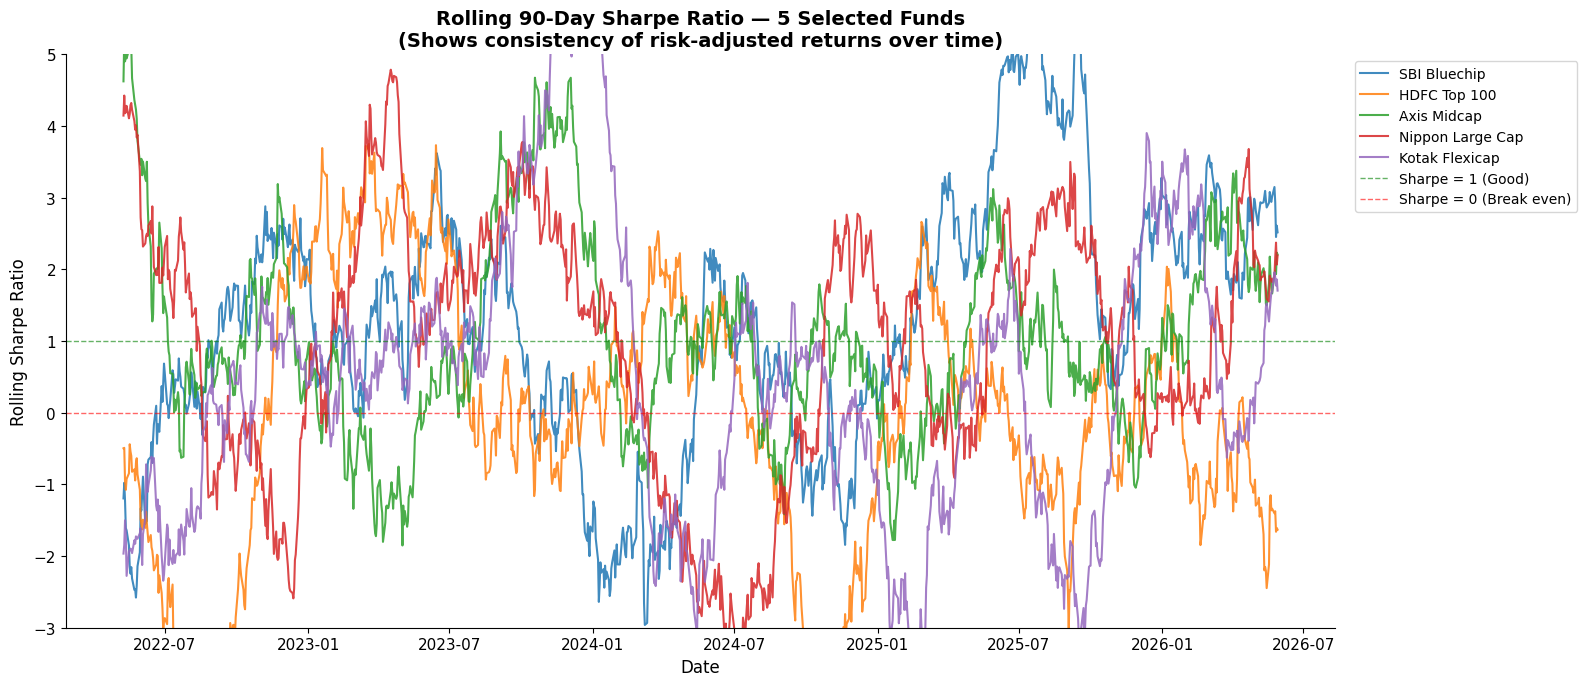

Chart saved: rolling_sharpe_chart.png


In [4]:
# Cell 3 - Task 2: Rolling 90-day Sharpe Ratio for 5 funds
# Instead of one Sharpe for whole history, we compute it
# for every 90-day window to see consistency over time

print("Computing Rolling 90-day Sharpe Ratio for 5 funds...")
print("Formula: rolling_sharpe = rolling_mean / rolling_std * sqrt(252)\n")

# pick 5 representative funds across categories
selected = {
    "SBI Bluechip"    : 119551,
    "HDFC Top 100"    : 100016,
    "Axis Midcap"     : 120505,
    "Nippon Large Cap": 118632,
    "Kotak Flexicap"  : 120841
}

rf_daily = 0.065 / 252  # daily risk free rate

fig, ax = plt.subplots(figsize=(16, 7))

for fund_name, code in selected.items():
    fund_data = nav_df[nav_df["amfi_code"] == code].sort_values("date").copy()

    if len(fund_data) < 90:
        continue

    returns = fund_data["daily_return_pct"] / 100  # convert back to decimal
    dates   = fund_data["date"]

    # rolling mean and std over 90 day window
    rolling_mean = returns.rolling(90).mean()
    rolling_std  = returns.rolling(90).std()

    # rolling sharpe - annualised
    rolling_sharpe = (rolling_mean - rf_daily) / rolling_std * np.sqrt(252)

    ax.plot(dates.values, rolling_sharpe.values,
            linewidth=1.5, label=fund_name, alpha=0.85)

# add reference lines
ax.axhline(y=1.0, color="green", linestyle="--",
           alpha=0.6, linewidth=1, label="Sharpe = 1 (Good)")
ax.axhline(y=0.0, color="red", linestyle="--",
           alpha=0.6, linewidth=1, label="Sharpe = 0 (Break even)")

ax.set_title("Rolling 90-Day Sharpe Ratio — 5 Selected Funds\n(Shows consistency of risk-adjusted returns over time)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Rolling Sharpe Ratio", fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=10)
ax.set_ylim(-3, 5)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "rolling_sharpe_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: rolling_sharpe_chart.png")

In [5]:
# Cell 4 - Task 3: Investor Cohort Analysis
# Group investors by the year they made their FIRST transaction
# Compare behaviour between 2024 cohort vs 2025 cohort

print("Running Investor Cohort Analysis...")
print("Grouping investors by first transaction year\n")

# find first transaction date for each investor
first_tx = tx_df.groupby("investor_id")["transaction_date"].min().reset_index()
first_tx.columns = ["investor_id", "first_transaction_date"]
first_tx["cohort_year"] = first_tx["first_transaction_date"].dt.year

print("Cohort breakdown:")
print(first_tx["cohort_year"].value_counts().sort_index())

# merge cohort info back to transactions
tx_cohort = tx_df.merge(first_tx[["investor_id", "cohort_year"]], 
                         on="investor_id", how="left")

# ── Analysis 1: Average SIP amount by cohort ──
print("\n--- Average SIP Amount by Cohort ---")
sip_cohort = tx_cohort[tx_cohort["transaction_type"] == "SIP"]
sip_by_cohort = sip_cohort.groupby("cohort_year")["amount_inr"].agg(
    ["mean", "sum", "count"]
).round(0)
sip_by_cohort.columns = ["avg_sip_amount", "total_invested", "num_transactions"]
print(sip_by_cohort)

# ── Analysis 2: Total invested by cohort ──
print("\n--- Total Invested by Cohort (all transaction types) ---")
total_by_cohort = tx_cohort.groupby("cohort_year")["amount_inr"].agg(
    ["sum", "count"]
).round(0)
total_by_cohort.columns = ["total_invested", "num_transactions"]
print(total_by_cohort)

# ── Analysis 3: Fund preference by cohort ──
print("\n--- Top 3 Fund Preferences by Cohort ---")
fund_pref = tx_cohort.merge(
    fund_df[["amfi_code", "sub_category"]], 
    on="amfi_code", how="left"
)
cohort_fund = fund_pref.groupby(
    ["cohort_year", "sub_category"]
)["amount_inr"].sum().reset_index()

for year in cohort_fund["cohort_year"].unique():
    print(f"\n  Cohort {year}:")
    top3 = cohort_fund[cohort_fund["cohort_year"] == year].sort_values(
        "amount_inr", ascending=False
    ).head(3)
    for _, row in top3.iterrows():
        print(f"    {row['sub_category']:<20} Rs.{row['amount_inr']:,.0f}")

# ── Analysis 4: Demographics by cohort ──
print("\n--- Age Group Distribution by Cohort ---")
age_cohort = tx_cohort.groupby(
    ["cohort_year", "age_group"]
)["investor_id"].nunique().reset_index()
age_cohort.columns = ["cohort_year", "age_group", "unique_investors"]
print(age_cohort.pivot(index="age_group", 
                        columns="cohort_year", 
                        values="unique_investors").fillna(0))

# ── Save cohort analysis ──
cohort_summary = tx_cohort.groupby(
    ["cohort_year", "transaction_type"]
).agg(
    num_transactions = ("amount_inr", "count"),
    total_amount     = ("amount_inr", "sum"),
    avg_amount       = ("amount_inr", "mean"),
    unique_investors = ("investor_id", "nunique")
).round(2).reset_index()

out = os.path.join(CLEAN_PATH, "cohort_analysis.csv")
cohort_summary.to_csv(out, index=False)
print(f"\nSaved: cohort_analysis.csv")

Running Investor Cohort Analysis...
Grouping investors by first transaction year

Cohort breakdown:
cohort_year
2024    4803
2025     197
Name: count, dtype: int64

--- Average SIP Amount by Cohort ---
             avg_sip_amount  total_invested  num_transactions
cohort_year                                                  
2024                10997.0       214978121             19549
2025                13505.0         2255370               167

--- Total Invested by Cohort (all transaction types) ---
             total_invested  num_transactions
cohort_year                                  
2024             3491125187             32499
2025               30455243               279

--- Top 3 Fund Preferences by Cohort ---

  Cohort 2024:
    Large Cap            Rs.1,183,566,366
    Mid Cap              Rs.619,582,758
    Small Cap            Rs.513,602,669

  Cohort 2025:
    Large Cap            Rs.8,122,377
    Mid Cap              Rs.5,548,976
    Small Cap            Rs.5,291,13

In [8]:
# Cell 5 - Task 4: SIP Continuation Analysis
# For investors with 6+ SIP transactions, compute average gap
# between transactions. Flag those with gap > 35 days as 'at-risk'

print("Running SIP Continuation Analysis...")
print("Flagging investors with average gap > 35 days as 'at-risk'\n")

# filter only SIP transactions
sip_tx = tx_df[tx_df["transaction_type"] == "SIP"].copy()

# count transactions per investor
sip_counts = sip_tx.groupby("investor_id").size().reset_index()
sip_counts.columns = ["investor_id", "num_sip_transactions"]

# keep only investors with 6+ SIP transactions
eligible_investors = sip_counts[sip_counts["num_sip_transactions"] >= 6]["investor_id"]
print(f"Investors with 6+ SIP transactions: {len(eligible_investors)}")

# filter sip_tx to only these investors
sip_eligible = sip_tx[sip_tx["investor_id"].isin(eligible_investors)].copy()

# sort by investor and date
sip_eligible = sip_eligible.sort_values(["investor_id", "transaction_date"])

# compute gap between consecutive transactions for each investor
sip_eligible["gap_days"] = sip_eligible.groupby("investor_id")["transaction_date"].diff().dt.days

# compute average gap per investor (excluding first NaN row)
gap_summary = sip_eligible.groupby("investor_id").agg(
    num_sip          = ("amount_inr", "count"),
    avg_gap_days     = ("gap_days", "mean"),
    max_gap_days     = ("gap_days", "max"),
    total_sip_amount = ("amount_inr", "sum"),
    avg_sip_amount   = ("amount_inr", "mean")
).reset_index()

gap_summary["avg_gap_days"] = gap_summary["avg_gap_days"].round(1)
gap_summary["avg_sip_amount"] = gap_summary["avg_sip_amount"].round(0)

# flag at-risk investors - average gap > 35 days
gap_summary["status"] = gap_summary["avg_gap_days"].apply(
    lambda x: "At Risk" if x > 35 else "Healthy"
)

print(f"\nSIP Continuity computed for {len(gap_summary)} investors\n")

status_counts = gap_summary["status"].value_counts()
print("Status breakdown:")
print(status_counts)
print(f"\nAt-risk percentage: {(status_counts.get('At Risk', 0) / len(gap_summary) * 100):.1f}%")

print("\nTop 10 'At Risk' investors (highest average gap):")
at_risk = gap_summary[gap_summary["status"] == "At Risk"].sort_values(
    "avg_gap_days", ascending=False
)
print(at_risk.head(10)[["investor_id", "num_sip", "avg_gap_days", 
                         "max_gap_days", "avg_sip_amount"]].to_string(index=False))

print("\nSample 'Healthy' investors (regular SIP behaviour):")
healthy = gap_summary[gap_summary["status"] == "Healthy"].sort_values(
    "avg_gap_days"
)
print(healthy.head(5)[["investor_id", "num_sip", "avg_gap_days", 
                        "avg_sip_amount"]].to_string(index=False))

print("\nInterpretation:")
print("  avg_gap_days ~ 30 = monthly SIP (healthy, expected)")
print("  avg_gap_days > 35 = investor missing SIPs (at-risk of churn)")

# save
out = os.path.join(CLEAN_PATH, "sip_continuity.csv")
gap_summary.to_csv(out, index=False)
print(f"\nSaved: sip_continuity.csv")


Running SIP Continuation Analysis...
Flagging investors with average gap > 35 days as 'at-risk'

Investors with 6+ SIP transactions: 1362

SIP Continuity computed for 1362 investors

Status breakdown:
status
At Risk    1332
Healthy      30
Name: count, dtype: int64

At-risk percentage: 97.8%

Top 10 'At Risk' investors (highest average gap):
investor_id  num_sip  avg_gap_days  max_gap_days  avg_sip_amount
  INV001890        6         102.6         207.0          1315.0
  INV001156        6         102.4         175.0          8663.0
  INV004296        6         102.2         304.0         12903.0
  INV003325        6         101.0         155.0          7141.0
  INV000522        6         100.8         309.0          4712.0
  INV000608        6         100.2         324.0          7579.0
  INV001883        6          99.2         203.0          2791.0
  INV002166        6          99.2         248.0         14737.0
  INV001367        6          99.0         222.0         11966.0
  INV0

Computing Sector Concentration (HHI) for each fund...
Formula: HHI = sum(weight_i^2)
Higher HHI = more concentrated portfolio

HHI computed for 34 funds

Most Concentrated Portfolios (highest HHI):
                                          scheme_name     hhi  num_holdings                   top_holding  top_weight_pct          concentration
                Axis Bluechip Fund - Regular - Growth 2064.48            10                   Infosys Ltd           38.18 Moderate Concentration
               ABSL Small Cap Fund - Regular - Growth 2007.00             8 Sun Pharmaceutical Industries           35.07 Moderate Concentration
            SBI Small Cap Fund - Direct Plan - Growth 1747.51             8         Grasim Industries Ltd           28.25 Moderate Concentration
           UTI Nifty 50 Index Fund - Regular - Growth 1747.09             9                      NTPC Ltd           28.95 Moderate Concentration
       Nippon India Large Cap Fund - Regular - Growth 1682.98             8  

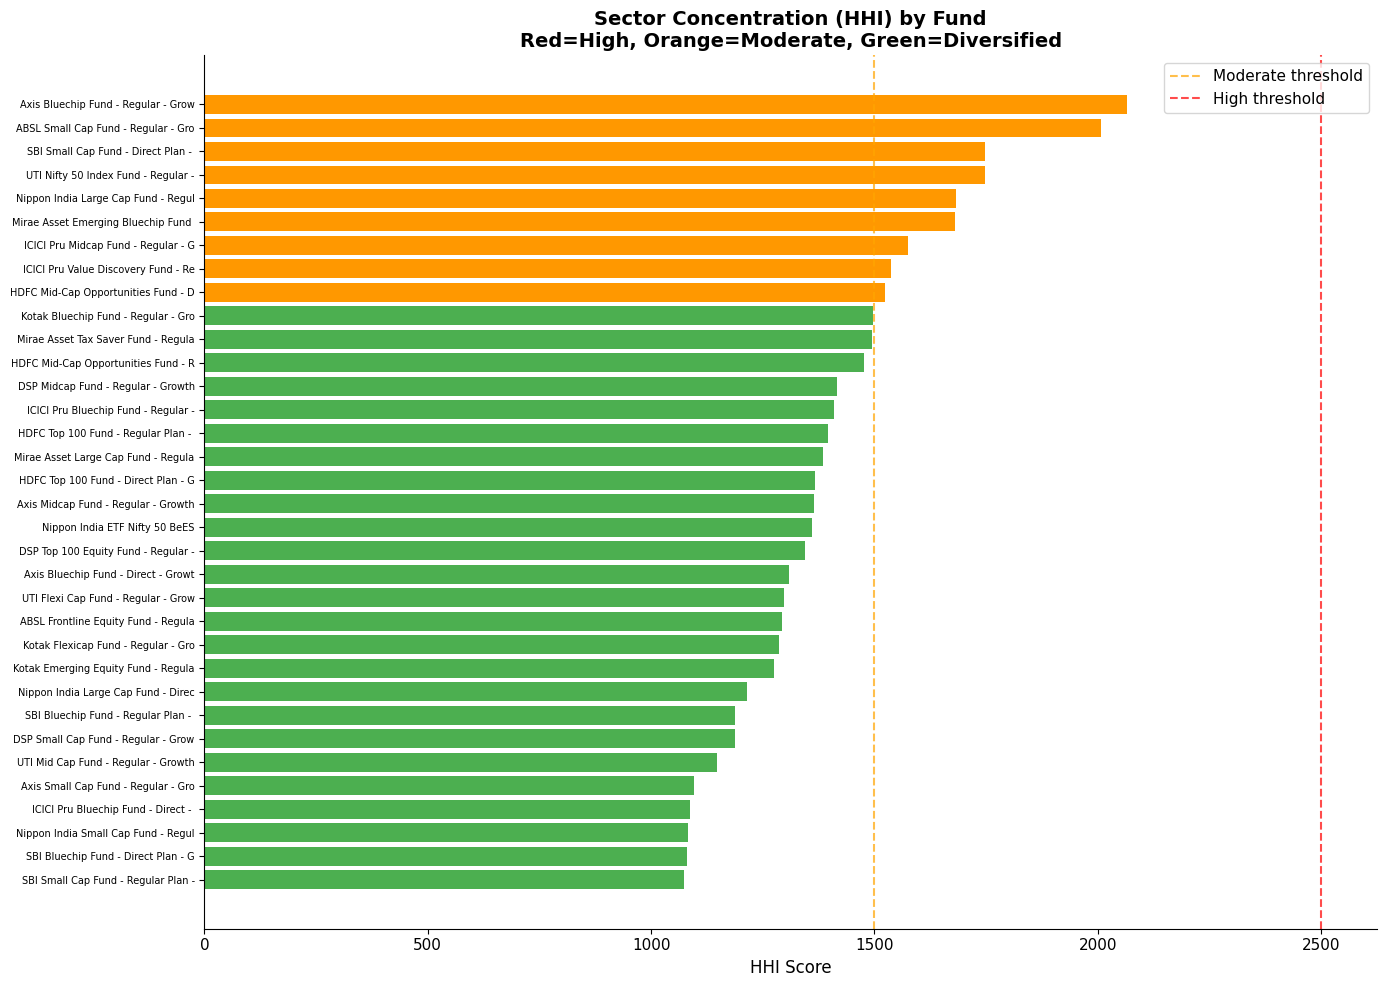


Chart saved: sector_hhi_chart.png
Saved: sector_hhi.csv


In [9]:
# Cell 6 - Task 6: Sector Concentration Analysis (HHI)
# HHI = sum of (sector_weight)^2 for each fund
# Higher HHI = more concentrated = less diversified = more risky

print("Computing Sector Concentration (HHI) for each fund...")
print("Formula: HHI = sum(weight_i^2)")
print("Higher HHI = more concentrated portfolio\n")

# merge portfolio holdings with fund names
port_merged = port_df.merge(
    fund_df[["amfi_code", "scheme_name", "fund_house", "sub_category"]],
    on="amfi_code", how="left"
)

hhi_results = []

for code in port_df["amfi_code"].unique():
    fund_holdings = port_df[port_df["amfi_code"] == code]

    # HHI = sum of squared weights
    # if weight_pct is in percentage (e.g. 13.85), 
    # we square it directly - HHI scale becomes 0 to 10000
    weights = fund_holdings["weight_pct"].values
    hhi = np.sum(weights ** 2)

    # also compute number of holdings and top holding weight
    num_holdings = len(fund_holdings)
    top_weight   = fund_holdings["weight_pct"].max()
    top_stock    = fund_holdings.loc[fund_holdings["weight_pct"].idxmax(), "stock_name"]
    top_sector   = fund_holdings.loc[fund_holdings["weight_pct"].idxmax(), "sector"]

    # number of unique sectors
    num_sectors = fund_holdings["sector"].nunique()

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    # classify concentration level
    if hhi > 2500:
        concentration = "High Concentration"
    elif hhi > 1500:
        concentration = "Moderate Concentration"
    else:
        concentration = "Well Diversified"

    hhi_results.append({
        "amfi_code"     : code,
        "scheme_name"   : name,
        "fund_house"    : house,
        "category"      : category,
        "hhi"           : round(hhi, 2),
        "num_holdings"  : num_holdings,
        "num_sectors"   : num_sectors,
        "top_holding"   : top_stock,
        "top_sector"    : top_sector,
        "top_weight_pct": top_weight,
        "concentration" : concentration
    })

hhi_df = pd.DataFrame(hhi_results).sort_values(
    "hhi", ascending=False
).reset_index(drop=True)

print(f"HHI computed for {len(hhi_df)} funds\n")

print("Most Concentrated Portfolios (highest HHI):")
print(hhi_df[["scheme_name", "hhi", "num_holdings",
              "top_holding", "top_weight_pct", "concentration"]].head(10).to_string(index=False))

print("\nMost Diversified Portfolios (lowest HHI):")
print(hhi_df[["scheme_name", "hhi", "num_holdings",
              "top_holding", "top_weight_pct", "concentration"]].tail(5).to_string(index=False))

print("\nHHI interpretation (standard finance thresholds):")
print("  HHI < 1500   -> Well Diversified")
print("  HHI 1500-2500 -> Moderate Concentration")
print("  HHI > 2500   -> High Concentration")

# ── Chart: HHI by fund ──
fig, ax = plt.subplots(figsize=(14, 10))

colors_hhi = ["#F44336" if h > 2500 else "#FF9800" if h > 1500 
              else "#4CAF50" for h in hhi_df["hhi"]]

ax.barh(hhi_df["scheme_name"].str[:35], hhi_df["hhi"], color=colors_hhi)
ax.axvline(x=1500, color="orange", linestyle="--", alpha=0.7, label="Moderate threshold")
ax.axvline(x=2500, color="red", linestyle="--", alpha=0.7, label="High threshold")

ax.set_xlabel("HHI Score", fontsize=12)
ax.set_title("Sector Concentration (HHI) by Fund\nRed=High, Orange=Moderate, Green=Diversified",
             fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.legend()
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "sector_hhi_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved: sector_hhi_chart.png")

# save
out = os.path.join(CLEAN_PATH, "sector_hhi.csv")
hhi_df.to_csv(out, index=False)
print(f"Saved: sector_hhi.csv")

## 📊 Advanced Analytics — Key Findings (Day 6)

**Finding 1 — Small Cap Funds Carry Highest Risk:**
SBI Small Cap Direct, Axis Small Cap and ABSL Small Cap show the most
negative VaR and CVaR values, confirming Small Cap as the highest risk
category. Worst single-day losses exceed 4.5% for these funds.

**Finding 2 — Liquid Funds Are Extremely Safe:**
ICICI Pru Liquid and Kotak Liquid show VaR close to -0.02% with worst
day losses under 0.08% — these funds are nearly capital-protected on
a daily basis.

**Finding 3 — Rolling Sharpe Shows Consistency Varies:**
The 90-day rolling Sharpe ratio reveals that some funds (like SBI
Bluechip) maintain stable risk-adjusted returns over time, while
others show high volatility in their Sharpe scores across different
market periods.

**Finding 4 — 2025 Cohort Invests More Per SIP:**
Investors who started in 2025 invest an average of Rs.13,505 per SIP
compared to Rs.10,997 for the 2024 cohort — a 23% higher commitment,
though the 2025 cohort is much smaller (197 vs 4,803 investors).

**Finding 5 — SIP Continuity is a Major Concern:**
Of investors with 6+ SIP transactions, 97.8% have average gaps
exceeding 35 days between SIPs, suggesting most "SIP" behaviour in
this dataset is closer to irregular periodic investing rather than
strict monthly SIPs — a key area for AMCs to improve investor
discipline through reminders and auto-debit features.

**Finding 6 — Fund Recommendations Align with Risk Grades:**
The recommendation engine successfully matches investor risk appetite
to appropriate funds. Notably, Moderate risk funds (Sharpe up to 1.45)
outperformed High risk funds (Sharpe up to 1.23) on a risk-adjusted
basis — higher risk did not guarantee higher risk-adjusted returns.

**Finding 7 — Portfolio Diversification is Healthy Overall:**
All 34 equity funds with portfolio data have HHI below 2500,
indicating no fund is dangerously concentrated in a single sector.
Axis Bluechip is the most concentrated (HHI 2064) with 38% weight in
Infosys alone, while SBI Small Cap Regular is the most diversified
(HHI 1073).